In [2]:
from moabb.analysis.results import Results
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import MotorImagery
from utils import print_results_summary

results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                                 mean    std  count
pipeline               dataset                                     
AUG Tang SVM Grid      BrainBot                 0.517  0.084      6
                       PhysionetMotorImagery16  0.576  0.101      6
CSP + LDA              BrainBot                 0.470  0.077      6
                       PhysionetMotorImagery    0.472  0.063     10
                       PhysionetMotorImagery16  0.471  0.065     10
                       Weibo2014_16             0.487  0.116     10
                       Weibo2014_64_5-classes   0.487  0.116     10
CSP + SVM Grid         BrainBot                 0.478  0.055      6
                       PhysionetMotorImagery    0.512  0.047     10
                       PhysionetMotorImagery16  0.504  0.042     10
                       Weibo2014_16             0.528  0.117     10
                       Weibo2014_64_5-classes   0.528  0.117     10
DLCSPauto + shLDA      BrainBot

In [3]:
results = Results(  
    evaluation_class=WithinSessionEvaluation,  
    paradigm_class=MotorImagery,  
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)

df = results.to_dataframe()  
print_results_summary(df)

Results Summary:
                                               mean    std  count
pipeline             dataset                                     
Keras_DeepConvNet    BrainBot                 0.226  0.037      6
                     PhysionetMotorImagery    0.175  0.094     10
                     PhysionetMotorImagery16  0.197  0.080     10
                     Weibo2014                0.236  0.097     10
                     Weibo2014_16             0.262  0.046     10
                     Weibo2014_64_5-classes   0.265  0.052     10
Keras_EEGITNet       BrainBot                 0.213  0.037      6
                     PhysionetMotorImagery    0.284  0.090     10
                     PhysionetMotorImagery16  0.340  0.102     10
                     Weibo2014                0.284  0.122     10
                     Weibo2014_16             0.304  0.079     10
                     Weibo2014_64_5-classes   0.304  0.079     10
Keras_EEGNeX         BrainBot                 0.214  0.035 

### Notes
AUG Tang SVM Grid pipeline seems to get stuck (executed for 7+ hours for one subject without any visible progress) thus results are not complete

### Analysis

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combine results from typical MI pipelines and Tensorflow pipelines
print("Reloading results to ensure we have all data...")
results_mi = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI"
)
df_mi = results_mi.to_dataframe()
df_mi['type'] = 'Standard MI'

results_tf = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)
df_tf = results_tf.to_dataframe()
df_tf['type'] = 'Tensorflow'

# Concatenate
all_results = pd.concat([df_mi, df_tf], ignore_index=True)

# Define Channel Counts / Groups
def categorize_dataset(dataset_name):
    if 'BrainBot' in dataset_name:
        return 'BrainBot (Target)'
    elif '16' in dataset_name:
        return '16 Channels (Low Density)'
    else:
        return '60+ Channels (High Density)'

all_results['Channel Group'] = all_results['dataset'].apply(categorize_dataset)

print("Combined Data Shape:", all_results.shape)
print("Datasets:", all_results['dataset'].unique())

Reloading results to ensure we have all data...
Combined Data Shape: (660, 11)
Datasets: <StringArray>
[           'Weibo2014_16',  'Weibo2014_64_5-classes',
                'BrainBot',   'PhysionetMotorImagery',
 'PhysionetMotorImagery16',               'Weibo2014']
Length: 6, dtype: str


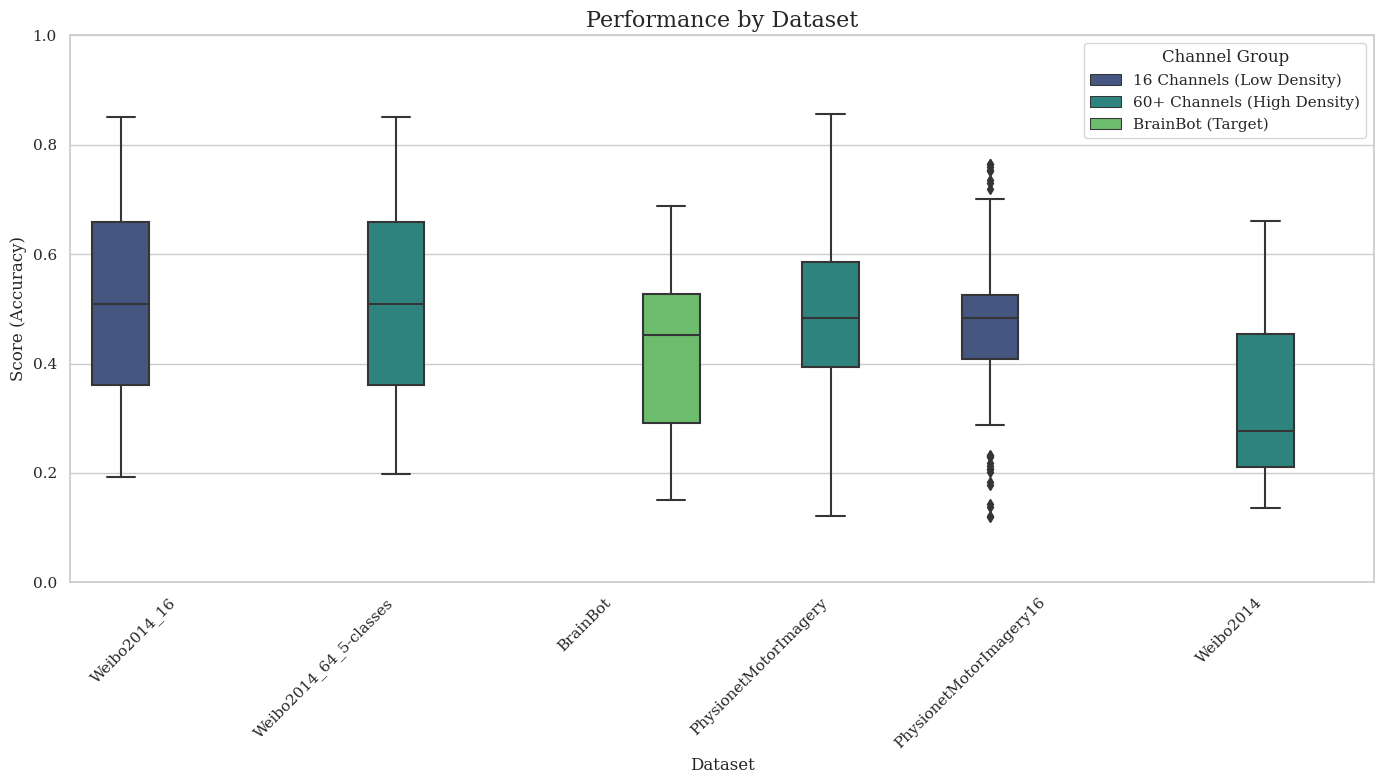

In [5]:
# 2. Dataset Performance Overview
plt.figure(figsize=(14, 8))
# Filter out the 7-class Weibo dataset for fair comparison or keep it but annotate
plot_data = all_results.copy()
# Rename for clarity in plot
plot_data['dataset_label'] = plot_data['dataset'].replace({
    'Weibo2014': 'Weibo2014 (7-class)',
    'Weibo2014_64_5-classes': 'Weibo 60ch (5-class)'
})

dataset_order = sorted(plot_data['dataset_label'].unique())

sns.boxplot(x='dataset', y='score', hue='Channel Group', data=plot_data, palette='viridis')
plt.title('Performance by Dataset', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Score (Accuracy)', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.legend(title='Channel Group', loc='upper right')
plt.ylim(0, 1)  # Assuming scores are between 0 and 1
plt.tight_layout()
plt.show()

=== Top Classifiers for BrainBot Dataset ===
                            mean       std  count
pipeline                                         
TS ElasticNet Grid      0.647710  0.128877     46
Tangent Space LR        0.646610  0.120246     46
Tangent Space SVM Grid  0.636889  0.119477     46
FgMDM                   0.590695  0.122696     46
AUG Tang SVM Grid       0.546795  0.093773     12
Keras_ShallowConvNet    0.528267  0.101280     56
CSP + SVM Grid          0.512604  0.083175     46
DLCSPauto + shLDA       0.483977  0.088452     46
CSP + LDA               0.477930  0.087579     46
MDM                     0.436733  0.129970     46
Keras_EEGNet_8_2        0.398672  0.134339     56
Keras_EEGNeX            0.349853  0.108966     56
Keras_EEGITNet          0.293515  0.093592     56
Keras_DeepConvNet       0.226690  0.078300     56


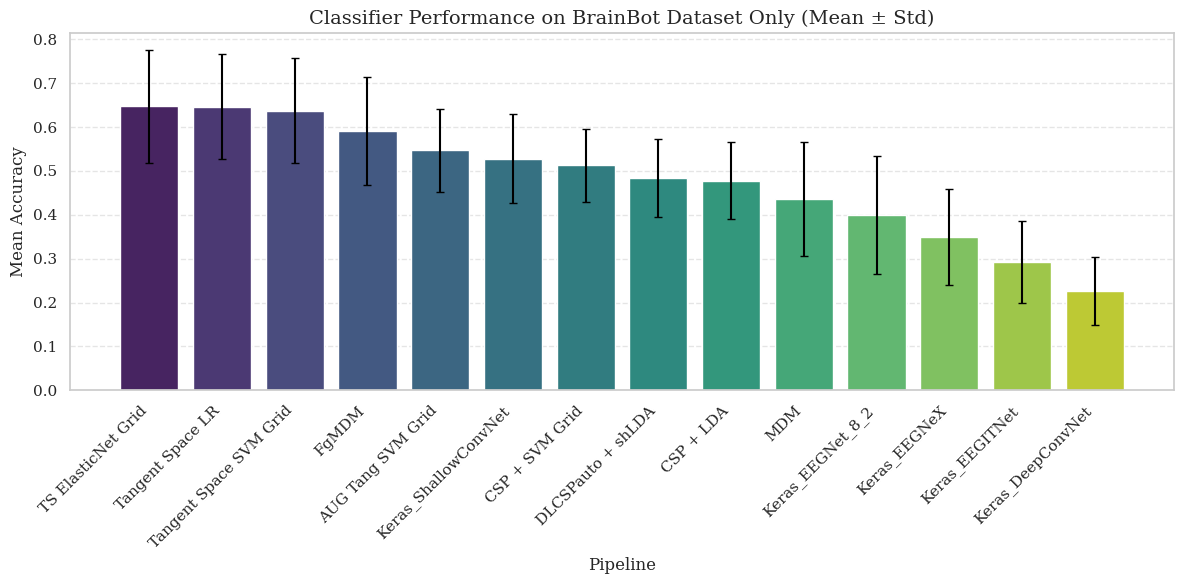

In [6]:

brainbot_performance = all_results.groupby('pipeline')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

print("=== Top Classifiers for BrainBot Dataset ===")
print(brainbot_performance)

# Visualization for BrainBot
plt.figure(figsize=(12, 6))
sns.barplot(x=brainbot_performance.index, y='mean', data=brainbot_performance, palette='viridis')
plt.errorbar(x=range(len(brainbot_performance)), y=brainbot_performance['mean'], 
                yerr=brainbot_performance['std'], fmt='none', ecolor='black', capsize=3)
plt.title('Classifier Performance on BrainBot Dataset Only (Mean ± Std)', fontsize=14)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.xlabel('Pipeline', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Porównanie montażu 16- i 64-elektrodowego
Rozkłady dokładności klasyfikacji dla porównywalnych, pięcioklasowych wersji zbiorów Weibo2014 i Physionet Motor Imagery.

In [7]:

# Per-subject classifier results (InitialFiltering dataset)
filt_df = all_results[all_results['dataset'].str.contains('InitialFiltering')].copy()

subjects = sorted(filt_df['subject'].unique(), key=lambda x: int(x))
pipelines = filt_df['pipeline'].unique().tolist()

# Sort pipelines by mean score descending for consistent ordering
pipeline_order = (
    filt_df.groupby('pipeline')['score'].mean()
    .sort_values(ascending=False)
    .index.tolist()
)

n_subjects = len(subjects)
fig, axes = plt.subplots(n_subjects, 1, figsize=(14, 3.5 * n_subjects), sharex=True)

colors = plt.cm.tab20.colors

for ax, subj in zip(axes, subjects):
    subj_df = filt_df[filt_df['subject'] == subj].set_index('pipeline')['score']
    scores = [subj_df.get(p, float('nan')) for p in pipeline_order]
    bars = ax.bar(pipeline_order, scores, color=colors[:len(pipeline_order)])
    ax.axhline(0.25, color='red', linestyle='--', linewidth=1, label='Chance (0.25)')
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'Subject {subj}', fontsize=11, loc='left')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    # Annotate bar values
    for bar, score in zip(bars, scores):
        if not np.isnan(score):
            ax.text(bar.get_x() + bar.get_width() / 2, score + 0.01,
                    f'{score:.2f}', ha='center', va='bottom', fontsize=7.5)

axes[-1].set_xlabel('Pipeline', fontsize=11)
plt.setp(axes[-1].get_xticklabels(), rotation=40, ha='right', fontsize=9)

handles = [plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1)]
fig.legend(handles, ['Chance (0.25)'], loc='upper right', fontsize=9)
fig.suptitle('Per-Subject Classifier Accuracy', fontsize=14, y=1.002)
plt.tight_layout()
plt.show()


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1400x0 with 0 Axes>

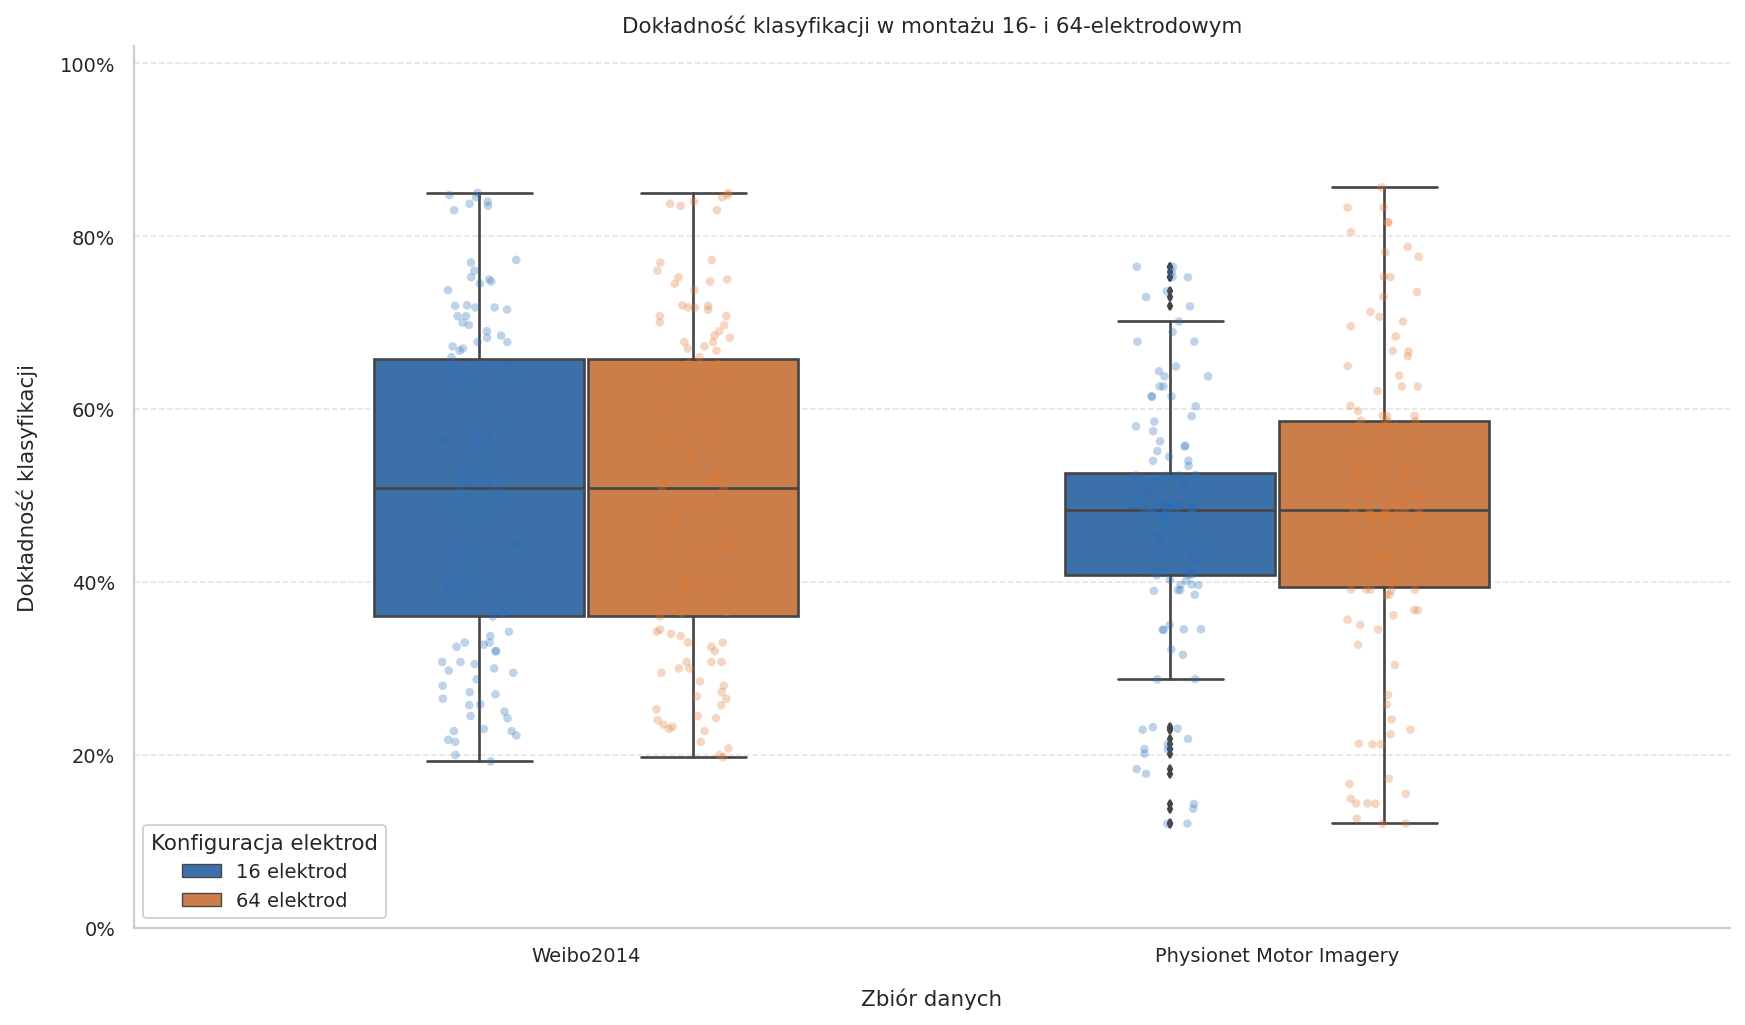

Średnia  Odchylenie standardowe  \
Zbiór danych            Montaż EEG                                     
Physionet Motor Imagery 16 elektrod    0.471                   0.139   
                        64 elektrod    0.486                   0.171   
Weibo2014               16 elektrod    0.508                   0.181   
                        64 elektrod    0.508                   0.181   

                                     Liczba wyników  
Zbiór danych            Montaż EEG                   
Physionet Motor Imagery 16 elektrod             136  
                        64 elektrod             130  
Weibo2014               16 elektrod             130  
                        64 elektrod             130

In [ ]:
# Porównanie dokładności: 16 elektrod vs pełny montaż (ponad 60 elektrod)
required_datasets = {
    'Weibo2014_16': ('Weibo2014', '16 elektrod'),
    'Weibo2014_64_5-classes': ('Weibo2014', '64 elektrod'),
    'PhysionetMotorImagery16': ('Physionet Motor Imagery', '16 elektrod'),
    'PhysionetMotorImagery': ('Physionet Motor Imagery', '64 elektrod'),
}

missing_datasets = set(required_datasets) - set(all_results['dataset'].unique())
if missing_datasets:
    raise ValueError(f'Brakuje wyników dla zbiorów: {sorted(missing_datasets)}')

comparison_data = all_results.loc[
    all_results['dataset'].isin(required_datasets), ['dataset', 'score']
].copy()
comparison_data[['Zbiór danych', 'Montaż EEG']] = comparison_data['dataset'].apply(
    lambda name: pd.Series(required_datasets[name])
)

dataset_order = ['Weibo2014', 'Physionet Motor Imagery']
montage_order = ['16 elektrod', '64 elektrod']
palette = {
    '16 elektrod': '#2A6FBB',
    '64 elektrod': '#E07A35',
}

sns.set_theme(style='whitegrid', context='paper')
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=160)

sns.boxplot(
    data=comparison_data, x='Zbiór danych', y='score', hue='Montaż EEG',
    order=dataset_order, hue_order=montage_order, palette=palette,
    width=0.62, linewidth=1.2, fliersize=2.5, ax=ax,
 )

# Punkty z deterministycznym, niewielkim przesunięciem poziomym (zgodne z pandas 3).
rng = np.random.default_rng(8)
for dataset_index, dataset in enumerate(dataset_order):
    for montage_index, montage in enumerate(montage_order):
        scores = comparison_data.loc[
            (comparison_data['Zbiór danych'] == dataset)
            & (comparison_data['Montaż EEG'] == montage), 'score'
        ]
        x_position = dataset_index + (-0.155 if montage_index == 0 else 0.155)
        jitter = rng.uniform(-0.055, 0.055, size=len(scores))
        ax.scatter(
            x_position + jitter, scores, s=15, color=palette[montage],
            alpha=0.30, edgecolors='none', zorder=3
        )

ax.legend(title='Konfiguracja elektrod', loc='lower left',
          frameon=True, framealpha=0.95)

ax.set_title('Dokładność klasyfikacji w montażu 16- i 64-elektrodowym',
             fontsize=14, pad=14)
ax.set_xlabel('Zbiór danych', labelpad=10)
ax.set_ylabel('Dokładność klasyfikacji', labelpad=10)
ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.55)
ax.grid(axis='x', visible=False)
sns.despine(ax=ax, left=False, bottom=False)

# fig.text(
#     0.5, -0.02,
#     'Pudełko: kwartyle 25–75%; linia: mediana; punkty: pojedyncze wyniki klasyfikacji.',
#     ha='center', fontsize=10, color='#4C4C4C'
#  )
plt.tight_layout()
plt.show()

# Tabela pomocnicza do opisu wyników w pracy.
summary = (
    comparison_data.groupby(['Zbiór danych', 'Montaż EEG'])['score']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'Średnia', 'std': 'Odchylenie standardowe', 'count': 'Liczba wyników'})
    .round(3)
 )
display(summary)